![ab_testing_image](ab_testing_image.jpg)

As a Data Scientist at a leading online travel agency, you’ve been tasked with evaluating the impact of a new search ranking algorithm designed to improve conversion rates. The Product team is considering a full rollout, but only if the experiment shows a clear positive effect on the conversion rate and does not lead to a longer time to book.

They have shared A/B test datasets with session-level booking data (`"sessions_data.csv"`) and user-level control/variant split (`"users_data.csv"`). Your job is to analyze and interpret the results to determine whether the new ranking system delivers a statistically significant improvement and provide a clear, data-driven recommendation.

## `sessions_data.csv`

| column | data type | description | 
|--------|-----------|-------------|
| `session_id` | `string` | Unique session identifier (unique for each row) |
| `user_id` | `string` | Unique user identifier (non logged-in users have missing user_id values; each user can have multiple sessions) |
| `session_start_timestamp` | `string` | When a session started |
| `booking_timestamp` | `string` | When a booking was made (missing if no booking was made during a session) |
| `time_to_booking` | `float` | time from start of the session to booking, in minutes (missing if no booking was made during a session) |
| `conversion` | `integer` | _New column to create:_ did session end up with a booking (0 if booking_timestamp or time_to_booking is Null, otherwise 1) |

<br>

## `users_data.csv`

| column | data type | description | 
|--------|-----------|-------------|
| `user_id` | `string` | Unique user identifier (only logged-in users in this table) |
| `experiment_group` | `string` | control / variant split for the experiment (expected to be equal 50/50) |

<br>

The full on criteria are the following:
- Primary metric (conversion) effect must be statistically significant and show positive effect (increase).
- Guardrail (time_to_booking) effect must either be statistically insignificant or show positive effect (decrease)

In [141]:
import pandas as pd
from scipy.stats import chisquare
from pingouin import ttest
from statsmodels.stats.proportion import proportions_ztest

In [142]:
sessions = pd.read_csv('sessions_data.csv')
users = pd.read_csv('users_data.csv')

In [143]:
sessions.sample(5)

,session_id,user_id,session_start_timestamp,booking_timestamp,time_to_booking
4293,ucS7Uv0dXrz9bNou,NUezpDdvXWZxUrHU,2025-01-15 03:57:34.191923618,NaN,NaN
4460,Aduxwjr4IGfQcJ2z,pYMITQHOBVFjjqSq,2025-01-12 23:52:34.944314718,NaN,NaN
13710,8cA6MomymLrPiBsD,zoWdPolm21fQrKab,2025-01-16 00:33:03.328478098,2025-01-16 00:48:25.356589364,15.367135
6891,6W4jGAKDGWVSquN8,qVyvvniVBdrAjUbD,2025-01-17 08:32:39.810547113,NaN,NaN
10541,XlpIta0UoNpCuy8W,lY3kH3pHNN8sEIb2,2025-01-17 22:21:52.017449856,NaN,NaN


In [144]:
users.sample(5)

,user_id,experiment_group
827,7sN1FFu0bKSsy2xK,variant
6163,SpVyxVbyEU5MVg4f,variant
7233,RpP3LD4kizMgn6QB,variant
3685,uwNdK64jASKbb1E9,variant
6076,loXn4Npzegy2jG8n,variant


### Your solution

In [145]:
sessions_x_users = pd.merge(sessions, users, how='inner', on='user_id')
sessions_x_users['conversion'] = ((sessions_x_users['booking_timestamp'].notnull()) & 
                                  (sessions_x_users['time_to_booking'].notnull())).astype(int)
sessions_x_users.sample(5)

,session_id,user_id,session_start_timestamp,booking_timestamp,time_to_booking,experiment_group,conversion
8409,jD7ye7eeU5wTzA38,RZswVW0GQL8VZ0pO,2025-01-08 18:11:42.566459894,NaN,NaN,variant,0
6304,b1YSU7bTnxUF80Dk,AeZyByEv5F236OvX,2025-01-25 12:01:35.257009029,NaN,NaN,control,0
12991,IQK0rt5UeaxCRUqM,SVbXFO0rSCsMfzFl,2025-01-04 04:10:49.190496683,NaN,NaN,control,0
1364,TwlAytBElVHD3ouN,WXysFuM7TE7hnTrQ,2025-01-14 23:36:43.593759298,NaN,NaN,variant,0
9764,ZZAJ2Rh8BRrbi5gK,8y82Tjc5MaF8VQu2,2025-01-12 10:17:47.360858679,NaN,NaN,control,0


### EDA Graphs

In [146]:
import matplotlib.pyplot as plt

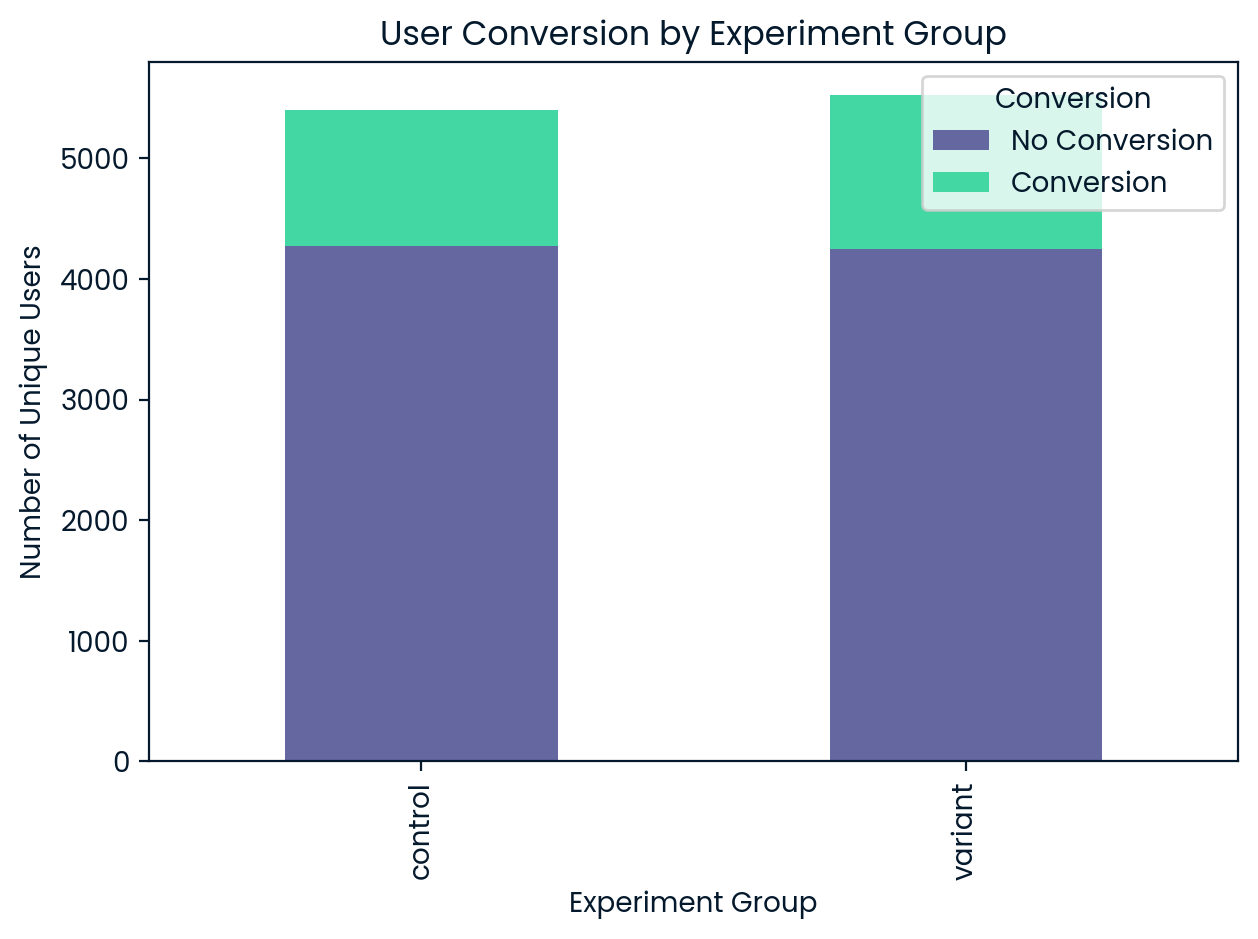

In [147]:
# Prepare data for stacked bar plot
conversion_counts = sessions_x_users.groupby(['experiment_group', 'conversion'])['user_id'].nunique().unstack(fill_value=0)

# Plot
conversion_counts.plot(kind='bar', stacked=True)
plt.xlabel('Experiment Group')
plt.ylabel('Number of Unique Users')
plt.title('User Conversion by Experiment Group')
plt.legend(title='Conversion', labels=['No Conversion', 'Conversion'])
plt.tight_layout()

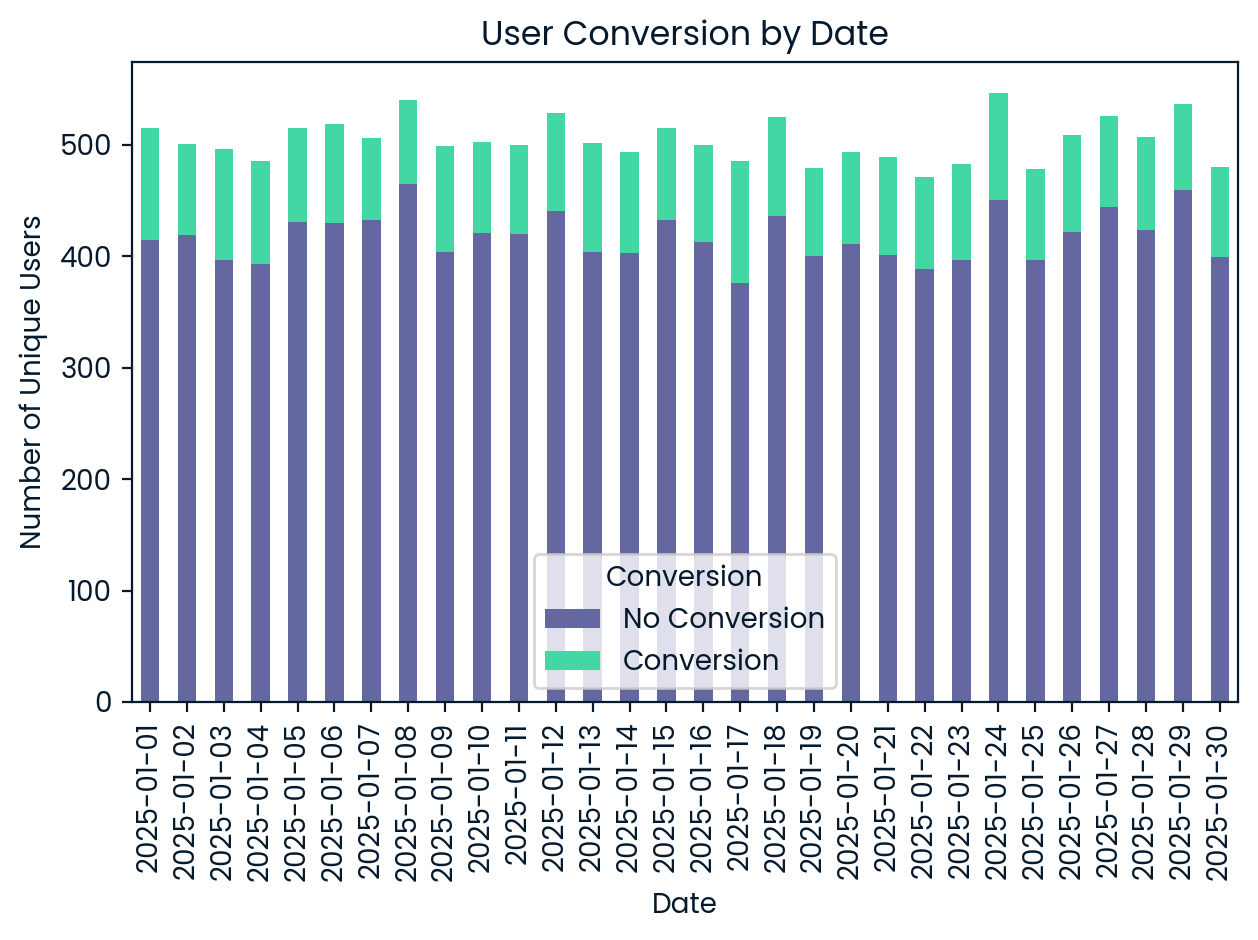

In [148]:
# Prepare data for stacked bar plot
sessions_x_users['session_start_date'] = pd.to_datetime(sessions_x_users['session_start_timestamp']).dt.date
conversion_counts = sessions_x_users.groupby(['session_start_date', 'conversion'])['user_id'].nunique().unstack(fill_value=0)

# Plot
conversion_counts.plot(kind='bar', stacked=True)
plt.xlabel('Date')
plt.ylabel('Number of Unique Users')
plt.title('User Conversion by Date')
plt.legend(title='Conversion', labels=['No Conversion', 'Conversion'])
plt.tight_layout()

## Sample Ratio Mismatch (SRM) test

In [149]:
# chi-squared test
n = sessions_x_users['experiment_group'].value_counts().sum()
expected = [n * 0.5, n * 0.5] 
srm_chi2_result = chisquare(sessions_x_users['experiment_group'].value_counts(), f_exp=expected)

In [150]:
srm_chi2_pval = srm_chi2_result.pvalue
print(srm_chi2_pval)

0.852407615775466


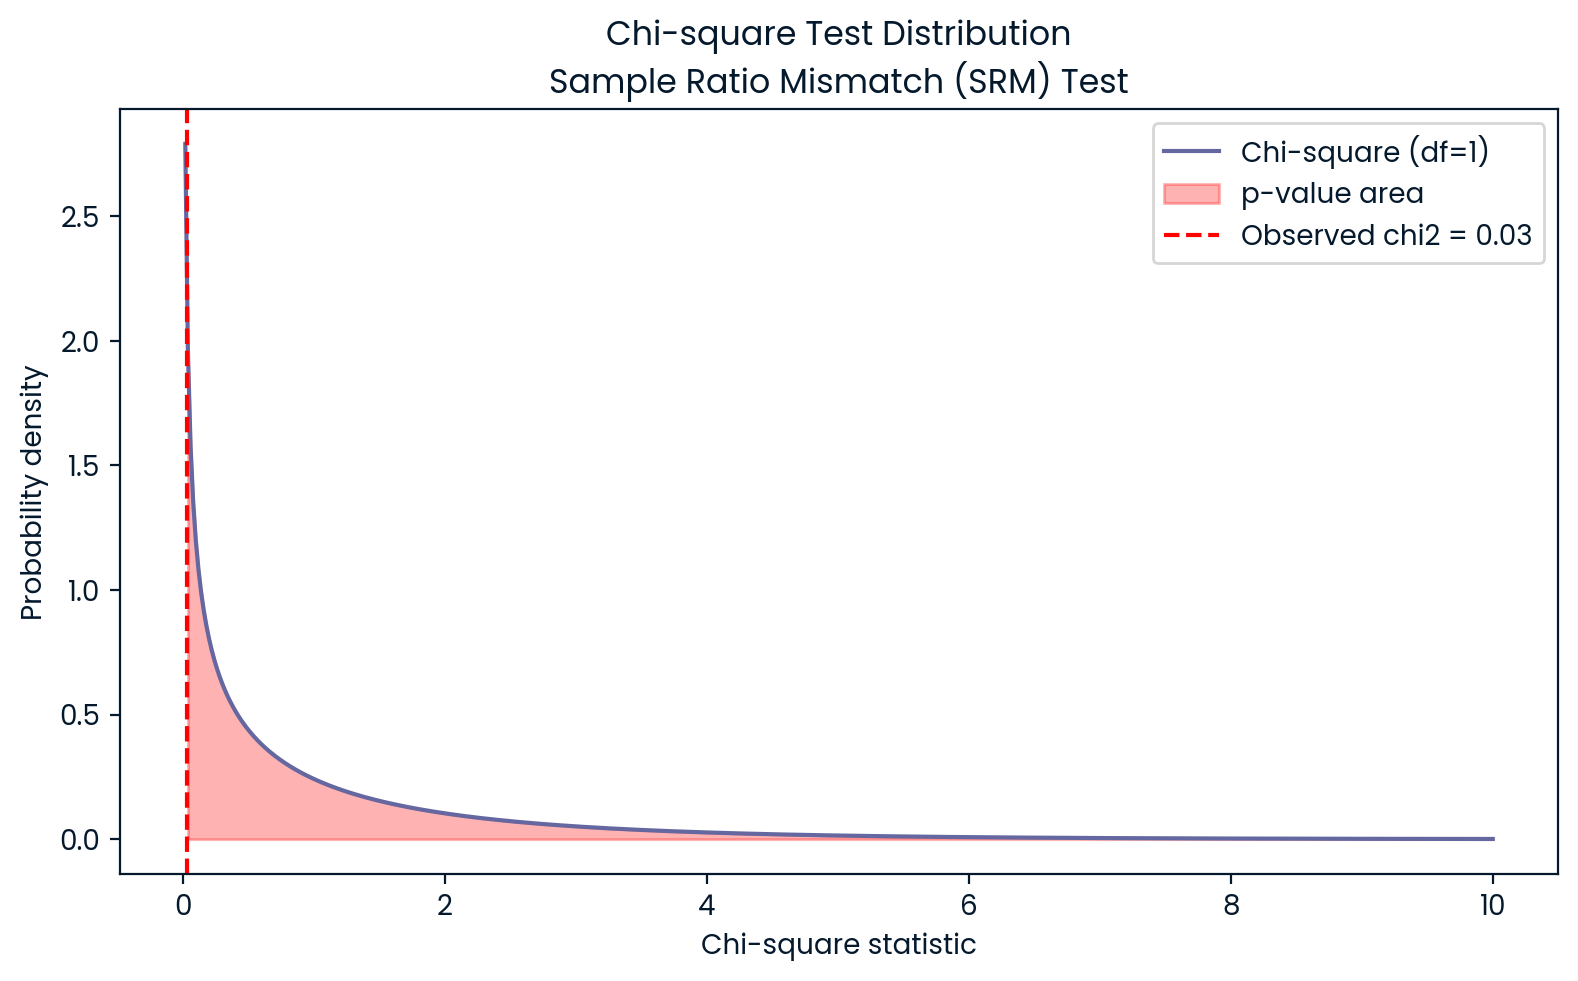

In [151]:
import numpy as np
import scipy.stats as stats

# Calculate observed and expected counts
observed = sessions_x_users['experiment_group'].value_counts().sort_index().values
n = observed.sum()
expected = np.array([n * 0.5, n * 0.5])

# Degrees of freedom
df = len(observed) - 1

# Chi-square statistic
chi2_stat = ((observed - expected) ** 2 / expected).sum()

# x values for chi-square distribution
x = np.linspace(0, 10, 500)
y = stats.chi2.pdf(x, df)

# Plot chi-square distribution
plt.figure(figsize=(8, 5))
plt.plot(x, y, label=f'Chi-square (df={df})')
plt.fill_between(x, y, where=(x >= chi2_stat), color='red', alpha=0.3, label='p-value area')
plt.axvline(chi2_stat, color='red', linestyle='--', label=f'Observed chi2 = {chi2_stat:.2f}')
plt.xlabel('Chi-square statistic')
plt.ylabel('Probability density')
plt.title('Chi-square Test Distribution\nSample Ratio Mismatch (SRM) Test')
plt.legend()
plt.tight_layout()

## Effect analysis on the primary metric - conversion rate

In [152]:
confidence_level = 0.90  # Set the pre-defined confidence level (90%)
alpha = 1 - confidence_level  # Significance level for hypothesis tests

In [153]:
conversion_prop = sessions_x_users.groupby('experiment_group')['conversion'].value_counts()
conversion_prop

experiment_group  conversion
control           0             6415
                  1             1215
variant           0             6261
                  1             1392
Name: conversion, dtype: int64

In [154]:
# Z-score
count = np.array([
        conversion_prop['variant'][1], 
        conversion_prop['control'][1]
])
nobs = np.array([
        conversion_prop['variant'].sum(), 
        conversion_prop['control'].sum()
])
stat_primary, pval_primary = proportions_ztest(
    count = count,
    nobs = nobs, 
    alternative='larger')

print(stat_primary, pval_primary)

3.722044623223758 9.880804396793696e-05


## Effect analysis on the guardrail metric - time to booking

In [155]:
sessions_x_users.groupby('experiment_group')['time_to_booking'].mean()

experiment_group
control    15.012404
variant    14.894029
Name: time_to_booking, dtype: float64

In [156]:
sessions_x_users.groupby('experiment_group')['time_to_booking'].apply(lambda s: s.isna().mean())

experiment_group
control    0.840760
variant    0.818111
Name: time_to_booking, dtype: float64

In [157]:
# t-test

x = sessions_x_users.loc[sessions_x_users['experiment_group'] == 'control', 'time_to_booking']
y = sessions_x_users.loc[sessions_x_users['experiment_group'] == 'variant', 'time_to_booking']

guardrail_result = ttest(
    x = x, 
    y = y, 
    paired=False, 
    alternative='two-sided', 
    correction='auto',  #Independent two-sample T-test with unequal sample size. A Welch's T-test is used. 
    confidence=0.9
)
guardrail_result

,T,dof,alternative,p-val,CI90%,cohen-d,BF10,power
T-test,0.618198,2575.103104,two-sided,0.5365,"[-0.19670201296355502, 0.4334525205064381]",0.024224,0.053,0.094593


In [158]:
pval_guardrail = guardrail_result.loc[:, 'p-val'].iloc[0]
pval_guardrail

0.5364997062996586

## Estimate the effect sizes on the primary and guardrail metrics

In [159]:
# Calculate ATE (Average Treatment Effect) for conversion and time_to_booking

# 1. Conversion rate per group
conversion_rate = sessions_x_users.groupby('experiment_group')['conversion'].mean()

# 2. time_to_booking mean per group
ttb_mean = sessions_x_users.groupby('experiment_group')['time_to_booking'].mean()

# 3. Calculate relative effect size (variant vs control)
effect_size_primary = (conversion_rate['variant'] - conversion_rate['control']) / conversion_rate['control']
effect_size_guardrail = (ttb_mean['variant'] - ttb_mean['control']) / ttb_mean['control']

print(f'''Average Treatment Effect
conversion: {effect_size_primary}
time_to_booking: {effect_size_guardrail}
''')

Average Treatment Effect
conversion: 0.14223583747517704
time_to_booking: -0.007885163098026412



## Robustness Check: Unit of Analysis (Session-level vs. User-level)

The experiment randomizes at the **user** level (`users_data.csv` assigns one `experiment_group` per `user_id`), but the primary metric test above (and the SRM check) was run on **session-level** data, where a single user can contribute up to 3 rows. Treating repeated sessions from the same user as independent observations violates the independence assumption behind the z-test / chi-squared test, and can distort the test statistic and p-value.

Below, we re-run both the SRM check and the primary metric test on data aggregated to the **user level** (the true unit of randomization), and compare the results side by side.

In [ ]:
# SRM check: session-level (as computed earlier) vs. user-level (correct unit)
srm_session_pval = srm_chi2_pval  # from the session-level SRM test above

user_level_counts = sessions_x_users.drop_duplicates('user_id')['experiment_group'].value_counts().sort_index()
n_users = user_level_counts.sum()
expected_users = [n_users * 0.5, n_users * 0.5]
srm_user_result = chisquare(user_level_counts, f_exp=expected_users)
srm_user_pval = srm_user_result.pvalue

print(f"SRM p-value (session-level, mis-specified): {srm_session_pval:.4f}")
print(f"SRM p-value (user-level, correct unit):     {srm_user_pval:.4f}")

### Primary metric (conversion) re-computed at the user level

In [ ]:
# Aggregate sessions up to one row per user: did this user convert in ANY of their sessions?
user_conversion = (
    sessions_x_users
    .groupby('user_id')
    .agg(experiment_group=('experiment_group', 'first'),
         converted=('conversion', 'max'))
    .reset_index()
)

user_conversion_prop = user_conversion.groupby('experiment_group')['converted'].value_counts()
user_conversion_prop

In [ ]:
# Z-test on the correctly-specified (user-level) unit of analysis
count_user = np.array([
    user_conversion_prop['variant'][1],
    user_conversion_prop['control'][1]
])
nobs_user = np.array([
    user_conversion_prop['variant'].sum(),
    user_conversion_prop['control'].sum()
])

stat_primary_user, pval_primary_user = proportions_ztest(
    count=count_user,
    nobs=nobs_user,
    alternative='larger'
)

print(stat_primary_user, pval_primary_user)

In [ ]:
# Effect size (ATE) at the user level
conversion_rate_user = user_conversion.groupby('experiment_group')['converted'].mean()
effect_size_primary_user = (
    (conversion_rate_user['variant'] - conversion_rate_user['control'])
    / conversion_rate_user['control']
)
effect_size_primary_user

In [ ]:
# Side-by-side comparison: session-level (mis-specified) vs. user-level (correct)
comparison = pd.DataFrame({
    'unit_of_analysis': ['session-level (mis-specified)', 'user-level (correct)'],
    'n_control': [nobs[1], nobs_user[1]],
    'n_variant': [nobs[0], nobs_user[0]],
    'z_stat': [stat_primary, stat_primary_user],
    'p_value': [pval_primary, pval_primary_user],
    'effect_size_ATE': [effect_size_primary, effect_size_primary_user]
})
comparison

**Takeaway:** both versions lead to the same full-on decision at the 90% confidence level, but the session-level test inflates the z-statistic (by treating repeat sessions from the same user as independent draws) and understates the p-value by roughly an order of magnitude. Because the experiment was randomized at the user level, the **user-level result is the statistically valid one** and should be treated as the primary finding; the session-level version is kept above only for comparison / as a cautionary example of a unit-of-analysis mismatch.

## Decision

In [160]:
print(f'''
Primary Metric (conversion)
p_value: pval_primary < alpha is {pval_primary < alpha}, 
Average Treatment Effect: {effect_size_primary}

Guardrail Metric (time_to_booking)
p_value: pval_primary < alpha is {pval_guardrail < alpha},
Average Treatment Effect: {effect_size_guardrail}
''')


Primary Metric (conversion)
p_value: pval_primary < alpha is True, 
Average Treatment Effect: 0.14223583747517704

Guardrail Metric (time_to_booking)
p_value: pval_primary < alpha is False,
Average Treatment Effect: -0.007885163098026412



- Primary metric (conversion) effect is statistically significant and show positive effect (increase). 
- Guardrail (time_to_booking) effect must either be statistically insignificant or show positive effect (decrease).

In [161]:
decision_full_on = 'Yes'